# pop-cosmos vs COSMOS2020 (Farmer) comparison

## What I am doing here

- Quick recap of my previous pop-cosmos vs Wang (2024) run + clearing some confusion there
- Repeat the same style of main-sequence / starburst comparison using COSMOS2020 Farmer columns.
- Some simple tables + plots (as suggested last meeting "make visuals for cross match. plot the angular seperation between sources. ")

## Starburst definition used

$$
\Delta_{\mathrm{MS}} = \log_{10}(\mathrm{SFR}) - \log_{10}(\mathrm{SFR}_{\mathrm{Speagle}}(M_\star, z))
$$

starburst if 
$$
	 \Delta_{\mathrm{MS}} \ge 0.6
$$


## Quick recap: what my Wang numbers actually mean

In the Wang run, I first matched galaxies present in **both** datasets (pop-cosmos and Wang), then applied my Bin A cuts (`1 <= z < 2`, `9 <= log10M <= 11.5`).

That gave:
- `all_matched = 37,149` galaxies
- `N_SB = 8` starbursts (using pop-cosmos SFR + Speagle offset cut)

### What ?significant long-wavelength detection? means

For Wang, I defined `long-detected` as:
- detected in any of `250, 350, 500, 850 um` with `SNR >= 3`.

`SNR >= 3` means the measured signal is at least 3 times the noise level, so the detection is reasonably reliable.

Important:
- `long-detected` does **not** mean starburst at long wavelengths?.
- It only means the source is seen clearly in long-lambda data.

### Interpreting the results

$$
f_{\mathrm{SB}}^{N}({all-matched}) = 
\frac{8}{37149} = 0.0215\%
$$

- Out of all matched galaxies in Bin A, 8 are classified as starburst.

$$
f_{\mathrm{SB}}^{N}({long-detected}) = 
\frac{2}{2673} = 0.0748\%
$$

- In the long-lambda detected subset, 2 are starburst.

$$
f_{\mathrm{SB}}^{N}({not long-detected}) = 
\frac{6}{34476} = 0.0174\%
$$

- In the not-long-detected subset, 6 are starburst.

### So what is this telling me?

- All 37,149 have SFR values from pop-cosmos.
- Only 8 pass the starburst threshold under this definition.
- Long-lambda detection slightly changes the fraction, but all values are still very low.

So this is a **split-check**, not the final dust test.

To test dust or other factors missed in NIR/optical  classification, I would need an independent IR-based SFR from long-lambda data and then re-run starburst labels with that SFR and then compare if a source that was/wasn't classified as starburst changes when viewed under the new def'n at longer lambda


### Step 1: Setup imports and file paths

In this cell I load packages and define paths to pop-cosmos, COSMOS2020 Farmer, and output files.



In [2]:
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.cosmology import Planck18
from astropy.coordinates import SkyCoord
import astropy.units as u

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'catalog data').exists() and (p / 'pop_cosmos_notebook').exists():
            return p
    raise FileNotFoundError('Could not locate project root containing catalog data and pop_cosmos_notebook.')


ROOT = find_project_root(Path.cwd().resolve())
NB_DIR = ROOT / 'pop_cosmos_notebook'
OUT_DIR = NB_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

pop_h5 = ROOT / 'catalog data/real pop-cosmos data/mcmc_summaries.h5'
farmer_dat = ROOT / 'catalog data/Main pop cosmos/farmer.dat.gz'
farmer_readme = ROOT / 'catalog data/Main pop cosmos/ReadMe(COSMOS2020).txt'
wang_csv = OUT_DIR / 'popcosmos_wang_comparison_summary.csv'

print('ROOT:', ROOT)
print('pop_h5 exists:', pop_h5.exists())
print('farmer.dat.gz exists:', farmer_dat.exists())
print('ReadMe exists:', farmer_readme.exists())
print('wang summary exists:', wang_csv.exists())

ROOT: C:\Users\Mihir Koka\Desktop\IMPERIAL courses\Imperial-work\Research project\Project coding
pop_h5 exists: True
farmer.dat.gz exists: True
ReadMe exists: True
wang summary exists: True


### Step 2: Define helper functions

defining some reusable functions for Speagle relation, quality masks, and starburst summary tables.



In [3]:
def speagle_log10sfr(log10m, z):
    # Safe Speagle relation: returns NaN for invalid z/mass rows.
    m = np.asarray(log10m, dtype=float)
    zz = np.asarray(z, dtype=float)
    out = np.full_like(m, np.nan, dtype=float)

    good = np.isfinite(m) & np.isfinite(zz) & (zz >= 0)
    if np.any(good):
        t_gyr = Planck18.age(zz[good]).value
        out[good] = (0.84 - 0.026 * t_gyr) * m[good] - (6.51 - 0.11 * t_gyr)

    return out


def robust_sigma(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    return 1.4826 * np.nanmedian(np.abs(x - med))


def sf_base_mask(df, m_col='log10M', sfr_col='log10SFR', ssfr_col='log10sSFR', z_col='z'):
    return (
        np.isfinite(df[m_col])
        & np.isfinite(df[sfr_col])
        & np.isfinite(df[ssfr_col])
        & np.isfinite(df[z_col])
        & (df[z_col] >= 0.0)
        & (df[z_col] < 4.0)
        & (df[m_col] >= 8.5)
        & (df[m_col] <= 11.5)
        & (df[ssfr_col] > -11.0)
    )


def summarize_bins(df_std, dataset_label):
    # df_std must have columns: log10M, log10SFR, log10sSFR, z
    work = df_std.copy()
    work['log10SFR_speagle'] = speagle_log10sfr(work['log10M'].to_numpy(), work['z'].to_numpy())
    work['delta_ms'] = work['log10SFR'] - work['log10SFR_speagle']

    base = sf_base_mask(work)

    bins = {
        'binA_1<=z<2_9<=logM<=11.5': base & (work['z'] >= 1.0) & (work['z'] < 2.0) & (work['log10M'] >= 9.0) & (work['log10M'] <= 11.5),
        'binB_1.5<=z<2.5_logM>=10': base & (work['z'] >= 1.5) & (work['z'] < 2.5) & (work['log10M'] >= 10.0),
    }

    rows = []
    for name, m in bins.items():
        n = int(m.sum())
        sb = m & (work['delta_ms'] >= 0.6)
        n_sb = int(sb.sum())

        sfr_total = np.sum(10 ** work.loc[m, 'log10SFR'].to_numpy()) if n > 0 else np.nan
        sfr_sb = np.sum(10 ** work.loc[sb, 'log10SFR'].to_numpy()) if n_sb > 0 else 0.0

        rows.append(
            {
                'dataset': dataset_label,
                'group': name,
                'N': n,
                'N_starburst': n_sb,
                'starburst_frac': (n_sb / n) if n > 0 else np.nan,
                'starburst_sfr_share': (sfr_sb / sfr_total) if (n > 0 and sfr_total > 0) else np.nan,
                'delta_ms_median': float(np.nanmedian(work.loc[m, 'delta_ms'])) if n > 0 else np.nan,
                'delta_ms_sigma': float(robust_sigma(work.loc[m, 'delta_ms'])) if n > 0 else np.nan,
                'z_median': float(np.nanmedian(work.loc[m, 'z'])) if n > 0 else np.nan,
                'log10M_median': float(np.nanmedian(work.loc[m, 'log10M'])) if n > 0 else np.nan,
            }
        )

    return pd.DataFrame(rows), work


### Step 3: Quick Wang recap table

This loads my previous Wang comparison summary, so I can compare old vs new in one place.


In [4]:
if wang_csv.exists():
    wang_summary = pd.read_csv(wang_csv)
    display(wang_summary)
else:
    print('Wang summary CSV not found.')

,group,N,N_starburst,starburst_frac,starburst_sfr_share,delta_ms_median,delta_ms_sigma,z_median,log10M_median
0,binA_1<=z<2_9<=logM<=11.5__all_matched,37149,8,0.000215,0.002628,-0.422144,0.341821,1.434134,10.182155
1,binA_1<=z<2_9<=logM<=11.5__long_detect_spire_s...,2673,2,0.000748,0.002761,-0.282609,0.339049,1.428098,10.742480
2,binA_1<=z<2_9<=logM<=11.5__not_long_detect_spi...,34476,6,0.000174,0.002596,-0.431654,0.339263,1.434651,10.142872
3,binB_1.5<=z<2.5_logM>=10__all_matched,15807,3,0.000190,0.001695,-0.330509,0.333989,1.893191,10.408814
4,binB_1.5<=z<2.5_logM>=10__long_detect_spire_sc...,1494,0,0.000000,0.000000,-0.279163,0.324633,1.831763,10.731050
5,binB_1.5<=z<2.5_logM>=10__not_long_detect_spir...,14313,3,0.000210,0.002057,-0.334973,0.333740,1.901097,10.377015


Output note:

- This is the baseline Wang table from the previous run.


### Step 4: Load pop-cosmos columns

I load only the pop-cosmos columns needed for matching and MS/starburst calculations.


In [5]:
# Load pop-cosmos summary fields
with h5py.File(pop_h5, 'r') as f:
    pop_df = pd.DataFrame(
        {
            'ID': f['metadata/index_farmer'][:].astype(np.int64),
            'ra_pop': f['metadata/ra'][:],
            'dec_pop': f['metadata/dec'][:],
            'log10M_pop': f['pop-cosmos/log10M_remain'][:, 2],
            'log10SFR_pop': f['pop-cosmos/log10SFR'][:, 2],
            'log10sSFR_pop': f['pop-cosmos/log10sSFR'][:, 2],
            'z_pop': f['pop-cosmos/z'][:, 2],
        }
    )

pop_df = pop_df[pop_df['ID'] > 0].copy()
print('pop-cosmos rows (ID>0):', f"{len(pop_df):,}")
pop_df.head()

pop-cosmos rows (ID>0): 429,669


,ID,ra_pop,dec_pop,log10M_pop,log10SFR_pop,log10sSFR_pop,z_pop
0,1,150.477585,2.328928,9.133266,-0.271097,-9.403467,1.591118
1,3,150.477020,2.329483,8.252427,-1.113287,-9.368039,0.222593
2,12,150.476807,2.331511,9.181695,-0.638846,-9.817816,0.695131
3,19,150.478317,2.333340,9.067933,0.301802,-8.751367,2.320230
4,20,150.727982,1.792131,8.689946,-2.235367,-10.622340,0.760776


Row count is the pop-cosmos sample entering this notebook.


### Step 5: Load COSMOS2020 Farmer columns

I read selected fixed-width columns from `farmer.dat.gz` and clean missing values.

I keep both LePhare lp_ and EAZY ez_ parameter sets.


In [6]:
# Load only needed COSMOS2020 Farmer columns (fixed-width positions from ReadMe)
farmer_colspecs = [
    (0, 6),      # ID
    (69, 81),    # RAdeg (ALPHA_DETECTION)
    (82, 92),    # DEdeg (DELTA_DETECTION)
    (2420, 2426),# lp_zPDF
    (2649, 2657),# lp_mass_med
    (2685, 2694),# lp_SFR_med
    (2725, 2734),# lp_sSFR_med
    (2765, 2774),# ez_z_phot
    (3045, 3057),# ez_mass
    (3058, 3070),# ez_sfr
    (3071, 3083),# ez_ssfr
]

farmer_names = [
    'ID', 'ra_farmer', 'dec_farmer',
    'lp_zPDF', 'lp_mass_med', 'lp_SFR_med', 'lp_sSFR_med',
    'ez_z_phot', 'ez_mass', 'ez_sfr', 'ez_ssfr'
]

farmer_df = pd.read_fwf(
    farmer_dat,
    colspecs=farmer_colspecs,
    names=farmer_names,
    compression='gzip',
    dtype='object'
)

# Clean types
farmer_df['ID'] = pd.to_numeric(farmer_df['ID'], errors='coerce').astype('Int64')
for c in farmer_names[1:]:
    farmer_df[c] = pd.to_numeric(farmer_df[c].replace('---', np.nan), errors='coerce')

farmer_df = farmer_df[farmer_df['ID'].notna() & (farmer_df['ID'] > 0)].copy()
farmer_df['ID'] = farmer_df['ID'].astype(np.int64)

print('COSMOS2020 Farmer rows (ID>0):', f"{len(farmer_df):,}")
farmer_df.head()

COSMOS2020 Farmer rows (ID>0): 964,506


,ID,ra_farmer,dec_farmer,lp_zPDF,lp_mass_med,lp_SFR_med,lp_sSFR_med,ez_z_phot,ez_mass,ez_sfr,ez_ssfr
0,1,150.477638,2.328963,1.5930,8.57070,0.15870,-8.35894,1.598163,8.930508,-0.161725,-9.092233
1,2,150.477974,2.329169,0.1151,5.51014,-2.77550,-8.27277,0.111465,5.435944,-3.056296,-8.492240
2,3,150.477111,2.329667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,150.477316,2.330574,0.0177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,150.474843,2.332179,2.8698,8.08458,0.41515,-7.65374,2.455822,8.085879,0.145153,-7.940726


### Step 6: Cross-match by ID

I match pop-cosmos and COSMOS2020 using Farmer ID with an inner join.


In [7]:
# Cross-match by ID
matched = pop_df.merge(farmer_df, on='ID', how='inner', validate='one_to_one')

n_pop = len(pop_df)
n_farmer = len(farmer_df)
n_match = len(matched)

linkage = pd.DataFrame(
    {
        'metric': [
            'pop-cosmos rows (ID>0)',
            'COSMOS2020 farmer rows (ID>0)',
            'matched rows (inner join by ID)',
            'match fraction of pop-cosmos',
            'match fraction of farmer',
        ],
        'value': [
            n_pop,
            n_farmer,
            n_match,
            n_match / n_pop,
            n_match / n_farmer,
        ],
    }
)

linkage

,metric,value
0,pop-cosmos rows (ID>0),429669.000000
1,COSMOS2020 farmer rows (ID>0),964506.000000
2,matched rows (inner join by ID),429669.000000
3,match fraction of pop-cosmos,1.000000
4,match fraction of farmer,0.445481


- matched rows is the actual overlap sample used for comparisons.
- Match fractions show overlap relative to each parent catalog.


### Step 7: Angular-separation sanity check

I compute coordinate separation between matched pop-cosmos and Farmer positions.

This checks whether matched sources are spatially consistent.


In [8]:
# Angular separation check
c_pop = SkyCoord(ra=matched['ra_pop'].to_numpy() * u.deg, dec=matched['dec_pop'].to_numpy() * u.deg, frame='icrs')
c_farmer = SkyCoord(ra=matched['ra_farmer'].to_numpy() * u.deg, dec=matched['dec_farmer'].to_numpy() * u.deg, frame='icrs')

matched['sep_arcsec'] = c_pop.separation(c_farmer).arcsec

sep_stats = pd.DataFrame(
    {
        'stat': ['median (arcsec)', 'p90 (arcsec)', 'p99 (arcsec)', 'max (arcsec)'],
        'value': [
            np.nanmedian(matched['sep_arcsec']),
            np.nanpercentile(matched['sep_arcsec'], 90),
            np.nanpercentile(matched['sep_arcsec'], 99),
            np.nanmax(matched['sep_arcsec']),
        ],
    }
)

sep_stats

,stat,value
0,median (arcsec),0.034506
1,p90 (arcsec),0.101569
2,p99 (arcsec),0.288843
3,max (arcsec),17.711767


Small median/p90 separation means good coordinate consistency.


### Step 8: Visual cross-match checks

I plot the angular-separation histogram and matched sky footprint.


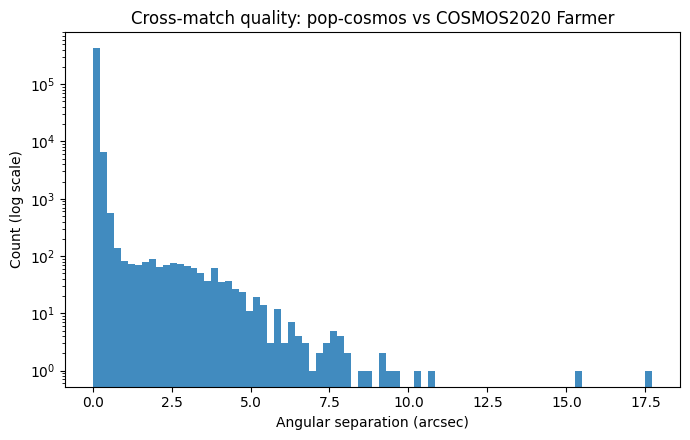

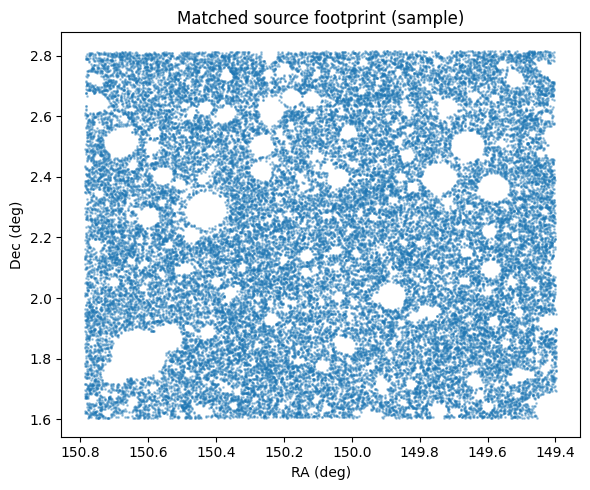

In [9]:
# Plot: angular separation histogram + sky footprint
plt.figure(figsize=(7, 4.5))
plt.hist(matched['sep_arcsec'], bins=80, color='#1f77b4', alpha=0.85)
plt.yscale('log')
plt.xlabel('Angular separation (arcsec)')
plt.ylabel('Count (log scale)')
plt.title('Cross-match quality: pop-cosmos vs COSMOS2020 Farmer')
plt.tight_layout()
plt.show()

plot_df = matched.sample(min(len(matched), 50000), random_state=7)
plt.figure(figsize=(6, 5))
plt.scatter(plot_df['ra_farmer'], plot_df['dec_farmer'], s=1, alpha=0.35)
plt.gca().invert_xaxis()
plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.title('Matched source footprint (sample)')
plt.tight_layout()
plt.show()

### Step 9: Run the same starburst comparison

I apply the same Speagle-based starburst logic to:
- pop-cosmos matched IDs
- COSMOS2020 LePhare
- COSMOS2020 EAZY


In [10]:
# Build standardized datasets for same starburst calculation
pop_std = matched.rename(
    columns={
        'log10M_pop': 'log10M',
        'log10SFR_pop': 'log10SFR',
        'log10sSFR_pop': 'log10sSFR',
        'z_pop': 'z',
    }
)[['ID', 'log10M', 'log10SFR', 'log10sSFR', 'z']].copy()

lp_std = matched.rename(
    columns={
        'lp_mass_med': 'log10M',
        'lp_SFR_med': 'log10SFR',
        'lp_sSFR_med': 'log10sSFR',
        'lp_zPDF': 'z',
    }
)[['ID', 'log10M', 'log10SFR', 'log10sSFR', 'z']].copy()

ez_std = matched.rename(
    columns={
        'ez_mass': 'log10M',
        'ez_sfr': 'log10SFR',
        'ez_ssfr': 'log10sSFR',
        'ez_z_phot': 'z',
    }
)[['ID', 'log10M', 'log10SFR', 'log10sSFR', 'z']].copy()

sum_pop, pop_work = summarize_bins(pop_std, 'pop-cosmos (on matched IDs)')
sum_lp, lp_work = summarize_bins(lp_std, 'COSMOS2020 LePhare (lp_*)')
sum_ez, ez_work = summarize_bins(ez_std, 'COSMOS2020 EAZY (ez_*)')

summary_all = pd.concat([sum_pop, sum_lp, sum_ez], ignore_index=True)
summary_all

,dataset,group,N,N_starburst,starburst_frac,starburst_sfr_share,delta_ms_median,delta_ms_sigma,z_median,log10M_median
0,pop-cosmos (on matched IDs),binA_1<=z<2_9<=logM<=11.5,107628,9,0.000084,0.002022,-0.597867,0.368175,1.424399,9.578845
1,pop-cosmos (on matched IDs),binB_1.5<=z<2.5_logM>=10,19300,3,0.000155,0.001559,-0.367738,0.355468,1.888443,10.351851
2,COSMOS2020 LePhare (lp_*),binA_1<=z<2_9<=logM<=11.5,74991,3743,0.049913,0.284998,-0.111255,0.401714,1.462800,9.547810
3,COSMOS2020 LePhare (lp_*),binB_1.5<=z<2.5_logM>=10,14360,477,0.033217,0.194083,-0.256843,0.486404,1.925200,10.409600
4,COSMOS2020 EAZY (ez_*),binA_1<=z<2_9<=logM<=11.5,92295,227,0.002460,0.046253,-0.489182,0.416712,1.432771,9.659993
5,COSMOS2020 EAZY (ez_*),binB_1.5<=z<2.5_logM>=10,21377,178,0.008327,0.062267,-0.378975,0.429014,1.916419,10.436245


How to read this table:

- `N`: number of galaxies in bin
- `N_starburst`: galaxies with $\Delta_{MS}\ge0.6$
- `starburst_frac`: fraction by number
- `starburst_sfr_share`: fraction of SFR from starbursts


### Step 10: Save summary table

I save the output table as CSV for notes/slides/reuse.


In [11]:
# Save summary table
out_csv = OUT_DIR / 'popcosmos_cosmos2020_comparison_summary.csv'
summary_all.to_csv(out_csv, index=False)
print('Saved:', out_csv)
summary_all

Saved: C:\Users\Mihir Koka\Desktop\IMPERIAL courses\Imperial-work\Research project\Project coding\pop_cosmos_notebook\outputs\popcosmos_cosmos2020_comparison_summary.csv


,dataset,group,N,N_starburst,starburst_frac,starburst_sfr_share,delta_ms_median,delta_ms_sigma,z_median,log10M_median
0,pop-cosmos (on matched IDs),binA_1<=z<2_9<=logM<=11.5,107628,9,0.000084,0.002022,-0.597867,0.368175,1.424399,9.578845
1,pop-cosmos (on matched IDs),binB_1.5<=z<2.5_logM>=10,19300,3,0.000155,0.001559,-0.367738,0.355468,1.888443,10.351851
2,COSMOS2020 LePhare (lp_*),binA_1<=z<2_9<=logM<=11.5,74991,3743,0.049913,0.284998,-0.111255,0.401714,1.462800,9.547810
3,COSMOS2020 LePhare (lp_*),binB_1.5<=z<2.5_logM>=10,14360,477,0.033217,0.194083,-0.256843,0.486404,1.925200,10.409600
4,COSMOS2020 EAZY (ez_*),binA_1<=z<2_9<=logM<=11.5,92295,227,0.002460,0.046253,-0.489182,0.416712,1.432771,9.659993
5,COSMOS2020 EAZY (ez_*),binB_1.5<=z<2.5_logM>=10,21377,178,0.008327,0.062267,-0.378975,0.429014,1.916419,10.436245


### Step 11: Visual MS comparison (Bin A)

I plot `log10(SFR)` vs `log10(M*)` with Speagle line for each method side-by-side.


C:\Users\Mihir Koka\AppData\Local\Temp\ipykernel_27376\4128268084.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


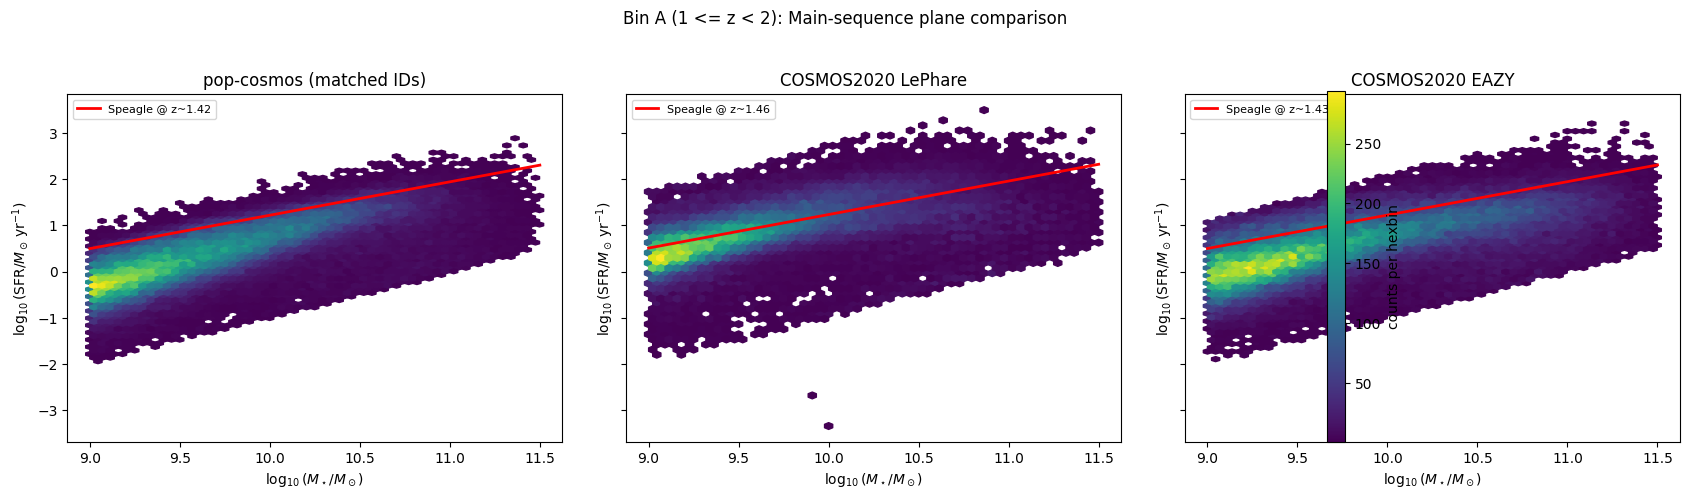

In [12]:
# Visual comparison in Bin A

def plot_ms_panel(ax, work_df, title):
    base = sf_base_mask(work_df)
    m = base & (work_df['z'] >= 1.0) & (work_df['z'] < 2.0) & (work_df['log10M'] >= 9.0) & (work_df['log10M'] <= 11.5)

    d = work_df.loc[m].copy()
    if len(d) == 0:
        ax.set_title(title + ' (no data)')
        return None

    hb = ax.hexbin(d['log10M'], d['log10SFR'], gridsize=55, mincnt=1, cmap='viridis')
    z_med = np.nanmedian(d['z'])
    x = np.linspace(9.0, 11.5, 120)
    y_s = speagle_log10sfr(x, np.full_like(x, z_med))
    ax.plot(x, y_s, 'r-', lw=2, label=f'Speagle @ z~{z_med:.2f}')

    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$')
    ax.set_ylabel(r'$\log_{10}(\mathrm{SFR}/M_\odot\,\mathrm{yr}^{-1})$')
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=8)
    return hb

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharex=True, sharey=True)

hb0 = plot_ms_panel(axes[0], pop_work, 'pop-cosmos (matched IDs)')
hb1 = plot_ms_panel(axes[1], lp_work, 'COSMOS2020 LePhare')
hb2 = plot_ms_panel(axes[2], ez_work, 'COSMOS2020 EAZY')

hb_ref = hb2 if hb2 is not None else hb1 if hb1 is not None else hb0
if hb_ref is not None:
    cbar = fig.colorbar(hb_ref, ax=axes.ravel().tolist(), shrink=0.95)
    cbar.set_label('counts per hexbin')

plt.suptitle('Bin A (1 <= z < 2): Main-sequence plane comparison', y=1.03)
plt.tight_layout()
plt.show()

How to read this figure:

- Red line is Speagle at median z.
- Vertical offset from red line shows normalization differences.


### Step 12: Compare $\Delta_{MS}$ distributions

I compare how each method sits relative to Speagle and the starburst threshold (`+0.6 dex`).


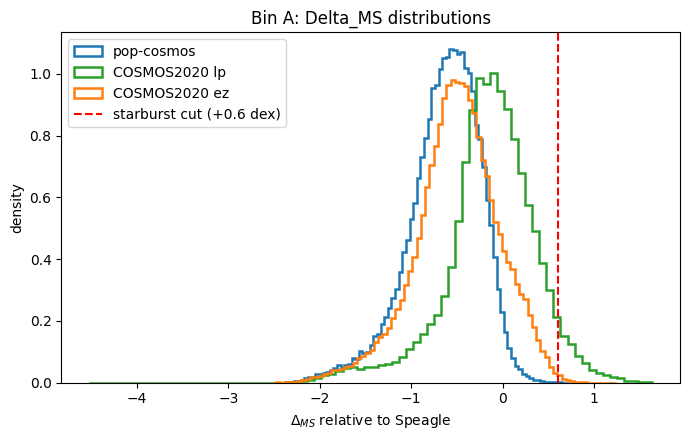

In [13]:
# Optional extra visual: Delta_MS distributions in Bin A

def delta_binA(work_df):
    base = sf_base_mask(work_df)
    m = base & (work_df['z'] >= 1.0) & (work_df['z'] < 2.0) & (work_df['log10M'] >= 9.0) & (work_df['log10M'] <= 11.5)
    return work_df.loc[m, 'delta_ms']

plt.figure(figsize=(7, 4.5))
for arr, lab, col in [
    (delta_binA(pop_work), 'pop-cosmos', '#1f77b4'),
    (delta_binA(lp_work), 'COSMOS2020 lp', '#2ca02c'),
    (delta_binA(ez_work), 'COSMOS2020 ez', '#ff7f0e'),
]:
    plt.hist(arr, bins=80, density=True, histtype='step', linewidth=1.8, label=lab, color=col)

plt.axvline(0.6, color='red', linestyle='--', label='starburst cut (+0.6 dex)')
plt.xlabel(r'$\Delta_{MS}$ relative to Speagle')
plt.ylabel('density')
plt.title('Bin A: Delta_MS distributions')
plt.legend()
plt.tight_layout()
plt.show()

Right side of dashed red line (`+0.6`) corresponds to starburst tail.


## Step 13: Direct SFR comparison across catalogs

Here I switch from the earlier starburst-style summary to a simpler direct comparison:

- pop-cosmos SFR vs COSMOS2020 LePhare SFR
- pop-cosmos SFR vs COSMOS2020 EAZY SFR

This is closer to Prof Clements suggestion: just cross-match and compare the SFR estimates directly.

Important caveat:
- the SFR methods are not identical, but big differenecs can still be useful to see

In [14]:
def paired_sfr_summary(df, left_col, right_col, z_col, m_col, label, subset_mask):
    m = subset_mask.fillna(False)
    d = (df.loc[m, left_col] - df.loc[m, right_col]).astype(float)
    d = d[np.isfinite(d)]

    if len(d) == 0:
        return {
            "pair": label,
            "subset": "empty",
            "N": 0,
            "median_dlogSFR": np.nan,
            "median_ratio": np.nan,
            "sigma_mad_dlogSFR": np.nan,
            "p16_dlogSFR": np.nan,
            "p84_dlogSFR": np.nan,
            "median_z": np.nan,
            "median_log10M": np.nan,
        }

    return {
        "pair": label,
        "N": int(m.sum()),
        "median_dlogSFR": float(np.nanmedian(d)),
        "median_ratio": float(10 ** np.nanmedian(d)),
        "sigma_mad_dlogSFR": float(1.4826 * np.nanmedian(np.abs(d - np.nanmedian(d)))),
        "p16_dlogSFR": float(np.nanpercentile(d, 16)),
        "p84_dlogSFR": float(np.nanpercentile(d, 84)),
        "median_z": float(np.nanmedian(df.loc[m, z_col])),
        "median_log10M": float(np.nanmedian(df.loc[m, m_col])),
    }


matched_sfr = matched.copy()
matched_sfr["dlogSFR_lp_minus_pop"] = matched_sfr["lp_SFR_med"] - matched_sfr["log10SFR_pop"]
matched_sfr["dlogSFR_ez_minus_pop"] = matched_sfr["ez_sfr"] - matched_sfr["log10SFR_pop"]

base_pop = (
    np.isfinite(matched_sfr["log10M_pop"])
    & np.isfinite(matched_sfr["log10SFR_pop"])
    & np.isfinite(matched_sfr["log10sSFR_pop"])
    & np.isfinite(matched_sfr["z_pop"])
    & (matched_sfr["log10M_pop"] >= 8.5)
    & (matched_sfr["log10M_pop"] <= 11.5)
    & (matched_sfr["z_pop"] >= 0.0)
    & (matched_sfr["z_pop"] < 4.0)
    & (matched_sfr["log10sSFR_pop"] > -11.0)
)

subsets = {
    "all_sf_like": base_pop,
    "binA_1<=z<2_9<=logM<=11.5": base_pop & (matched_sfr["z_pop"] >= 1.0) & (matched_sfr["z_pop"] < 2.0) & (matched_sfr["log10M_pop"] >= 9.0),
    "binB_1.5<=z<2.5_logM>=10": base_pop & (matched_sfr["z_pop"] >= 1.5) & (matched_sfr["z_pop"] < 2.5) & (matched_sfr["log10M_pop"] >= 10.0),
    "narrow_1.0<=z<1.5": base_pop & (matched_sfr["z_pop"] >= 1.0) & (matched_sfr["z_pop"] < 1.5) & (matched_sfr["log10M_pop"] >= 9.0),
    "narrow_1.5<=z<2.0": base_pop & (matched_sfr["z_pop"] >= 1.5) & (matched_sfr["z_pop"] < 2.0) & (matched_sfr["log10M_pop"] >= 9.0),
}

rows = []
for subset_name, subset_mask in subsets.items():
    row_lp = paired_sfr_summary(
        matched_sfr,
        "lp_SFR_med",
        "log10SFR_pop",
        "z_pop",
        "log10M_pop",
        "lp_minus_pop",
        subset_mask & np.isfinite(matched_sfr["lp_SFR_med"]),
    )
    row_lp["subset"] = subset_name
    rows.append(row_lp)

    row_ez = paired_sfr_summary(
        matched_sfr,
        "ez_sfr",
        "log10SFR_pop",
        "z_pop",
        "log10M_pop",
        "ez_minus_pop",
        subset_mask & np.isfinite(matched_sfr["ez_sfr"]),
    )
    row_ez["subset"] = subset_name
    rows.append(row_ez)

sfr_offset_summary = pd.DataFrame(rows)
sfr_offset_summary

,pair,N,median_dlogSFR,median_ratio,sigma_mad_dlogSFR,p16_dlogSFR,p84_dlogSFR,median_z,median_log10M,subset
0,lp_minus_pop,352826,0.223695,1.673766,0.360850,-0.159405,0.564419,1.402238,9.375257,all_sf_like
1,ez_minus_pop,347932,0.081692,1.206958,0.395299,-0.424292,0.454495,1.400931,9.381979,all_sf_like
2,lp_minus_pop,107130,0.318049,2.079931,0.276564,0.015010,0.592956,1.424479,9.577178,binA_1<=z<2_9<=logM<=11.5
3,ez_minus_pop,106440,0.137949,1.373880,0.336061,-0.250873,0.489952,1.424700,9.579921,binA_1<=z<2_9<=logM<=11.5
4,lp_minus_pop,19143,0.259909,1.819321,0.424925,-0.227242,0.654394,1.888595,10.350285,binB_1.5<=z<2.5_logM>=10
5,ez_minus_pop,19127,0.121574,1.323044,0.512750,-0.541789,0.628714,1.888252,10.351041,binB_1.5<=z<2.5_logM>=10
6,lp_minus_pop,61291,0.357978,2.280225,0.263986,0.051782,0.622979,1.253874,9.565037,narrow_1.0<=z<1.5
7,ez_minus_pop,60877,0.169988,1.479069,0.313755,-0.191511,0.498407,1.254208,9.567363,narrow_1.0<=z<1.5
8,lp_minus_pop,45839,0.256313,1.804316,0.271311,-0.014491,0.540317,1.713988,9.592356,narrow_1.5<=z<2.0
9,ez_minus_pop,45563,0.090561,1.231860,0.358195,-0.338858,0.476804,1.713447,9.595574,narrow_1.5<=z<2.0


What this table is saying:

- `median_dlogSFR` is the typical SFR offset between methods
- positive means the first method in `pair` gives a higher SFR
- `median_ratio` is the same thing but as a factor instead of dex
- `sigma_mad_dlogSFR` is the scatter in that offset

This is the cleanest "same galaxies, different SFR estimate" comparison in the current local data.

Saved: C:\Users\Mihir Koka\Desktop\IMPERIAL courses\Imperial-work\Research project\Project coding\pop_cosmos_notebook\outputs\popcosmos_cosmos2020_sfr_offsets_summary.csv


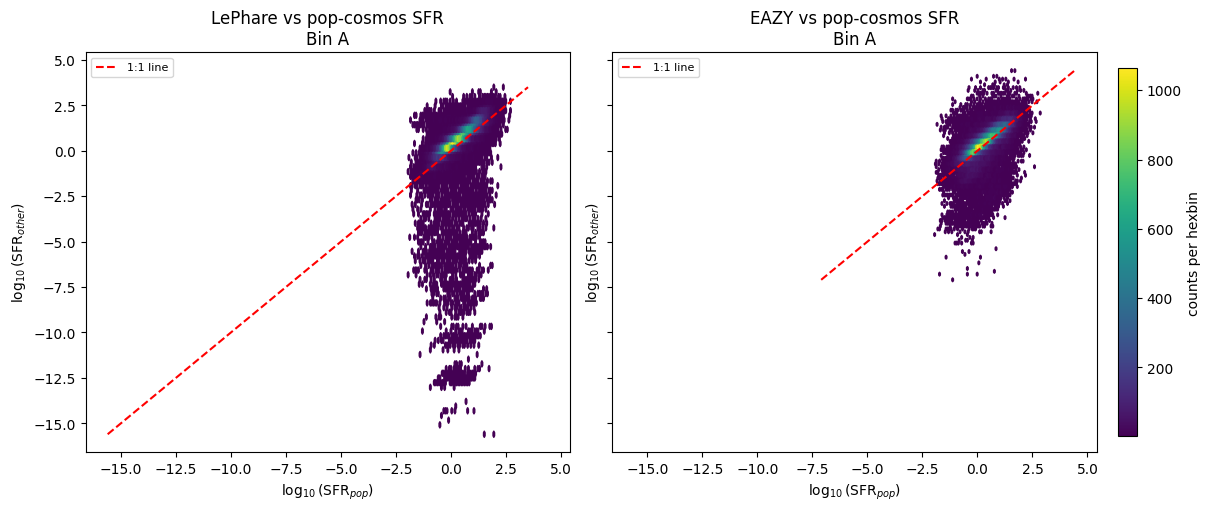

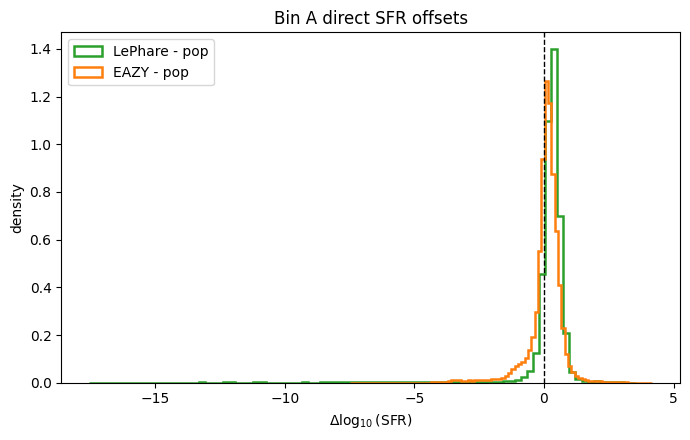

In [15]:
sfr_offset_csv = OUT_DIR / "popcosmos_cosmos2020_sfr_offsets_summary.csv"
sfr_offset_summary.to_csv(sfr_offset_csv, index=False)
print("Saved:", sfr_offset_csv)

binA_plot = subsets["binA_1<=z<2_9<=logM<=11.5"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True, constrained_layout=True)
for ax, ycol, title in [
    (axes[0], "lp_SFR_med", "LePhare vs pop-cosmos SFR"),
    (axes[1], "ez_sfr", "EAZY vs pop-cosmos SFR"),
]:
    d = matched_sfr.loc[binA_plot & np.isfinite(matched_sfr[ycol]), ["log10SFR_pop", ycol]].copy()
    hb = ax.hexbin(d["log10SFR_pop"], d[ycol], gridsize=65, mincnt=1, cmap="viridis")
    lo = np.nanmin([d["log10SFR_pop"].min(), d[ycol].min()])
    hi = np.nanmax([d["log10SFR_pop"].max(), d[ycol].max()])
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="1:1 line")
    ax.set_xlabel(r"$\log_{10}(\mathrm{SFR}_{pop})$")
    ax.set_ylabel(r"$\log_{10}(\mathrm{SFR}_{other})$")
    ax.set_title(title + "\nBin A")
    ax.legend(loc="upper left", fontsize=8)

cbar = fig.colorbar(hb, ax=axes, location="right", shrink=0.92, pad=0.02)
cbar.set_label("counts per hexbin")
plt.show()

plt.figure(figsize=(7, 4.5))
for col, label, color in [
    ("dlogSFR_lp_minus_pop", "LePhare - pop", "#2ca02c"),
    ("dlogSFR_ez_minus_pop", "EAZY - pop", "#ff7f0e"),
]:
    arr = matched_sfr.loc[binA_plot & np.isfinite(matched_sfr[col]), col]
    plt.hist(arr, bins=90, density=True, histtype="step", lw=1.8, label=label, color=color)
plt.axvline(0.0, color="k", ls="--", lw=1)
plt.xlabel(r"$\Delta \log_{10}(\mathrm{SFR})$")
plt.ylabel("density")
plt.title("Bin A direct SFR offsets")
plt.legend()
plt.tight_layout()
plt.show()

Quick interpretation of the plots:

- The bright yellow core is the densest part of the sample, so that is where most galaxies sit.
- In both panels, that core lies above the red `1:1` line, so for most galaxies the COSMOS2020 SFR estimate is higher than the pop-cosmos SFR estimate.
- The purple points far below the line are much lower-density outliers, so they matter less for the typical trend but they do show that a tail of galaxies has much lower COSMOS2020 SFR than pop-cosmos.
- The LePhare panel sits further above the line than the EAZY panel, so LePhare is systematically higher than pop-cosmos by more than EAZY is.

Short summary I can say out loud:

- Most matched galaxies sit above the `1:1` line, so COSMOS2020 usually gives a higher SFR than pop-cosmos for the same source.
- The main disagreement is strongest for LePhare, weaker for EAZY.
- There is still a lower-density tail below the line, so the difference is not identical for every galaxy, but the overall shift is clearly upward.

## Step 14: Wang direct comparison note + closest local test

The Wang data doesn't have a SFR field so for now i'll do

- cross-match Wang and pop-cosmos by ID
- compare pop-cosmos SFR against Wang long-wavelength fluxes / detection strength

This tests whether galaxies that pop-cosmos says are more star-forming also tend to look brighter in the far-IR/sub-mm.

In [16]:
import warnings
from astropy.table import Table

wang_master = ROOT / "catalog data/wang/master.dat.gz"
wang_readme = ROOT / "catalog data/wang/ReadMe.txt"

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    wang_tab = Table.read(wang_master, format="ascii.cds", readme=wang_readme)

wang_df = wang_tab.to_pandas()
wang_keep = ["ID", "F24", "s_F24", "F250", "s_F250", "F350", "s_F350", "F500", "s_F500", "F850", "s_F850"]
wang_df = wang_df[[c for c in wang_keep if c in wang_df.columns]].copy()
wang_df = wang_df[wang_df["ID"] > 0].copy()

for c in wang_df.columns:
    wang_df[c] = pd.to_numeric(wang_df[c], errors="coerce")

for lam in [24, 250, 350, 500, 850]:
    fcol = f"F{lam}"
    ecol = f"s_F{lam}"
    snr_col = f"SNR{lam}"
    if fcol in wang_df and ecol in wang_df:
        wang_df[snr_col] = wang_df[fcol] / wang_df[ecol].replace(0, np.nan)

wang_matched = pop_df.merge(wang_df, on="ID", how="inner")
wang_matched["long_detect"] = (
    (wang_matched.get("SNR250", np.nan) >= 3)
    | (wang_matched.get("SNR350", np.nan) >= 3)
    | (wang_matched.get("SNR500", np.nan) >= 3)
    | (wang_matched.get("SNR850", np.nan) >= 3)
)

def wang_flux_sfr_summary(df, band, base_mask):
    snr_col = f"SNR{band}"
    fcol = f"F{band}"
    m = base_mask & np.isfinite(df[fcol]) & np.isfinite(df[snr_col]) & (df[snr_col] >= 3) & (df[fcol] > 0)
    if m.sum() == 0:
        return {
            "band_um": band,
            "N_detect": 0,
            "median_log10SFR_pop": np.nan,
            "median_log10M_pop": np.nan,
            "median_z_pop": np.nan,
            "spearman_rho_logflux_vs_logSFR": np.nan,
        }
    tmp = df.loc[m, [fcol, "log10SFR_pop", "log10M_pop", "z_pop"]].copy()
    tmp[f"log10F{band}"] = np.log10(tmp[fcol])
    rho = tmp[f"log10F{band}"].corr(tmp["log10SFR_pop"], method="spearman")
    return {
        "band_um": band,
        "N_detect": int(m.sum()),
        "median_log10SFR_pop": float(np.nanmedian(tmp["log10SFR_pop"])),
        "median_log10M_pop": float(np.nanmedian(tmp["log10M_pop"])),
        "median_z_pop": float(np.nanmedian(tmp["z_pop"])),
        "spearman_rho_logflux_vs_logSFR": float(rho),
    }

wang_base = (
    np.isfinite(wang_matched["log10M_pop"])
    & np.isfinite(wang_matched["log10SFR_pop"])
    & np.isfinite(wang_matched["log10sSFR_pop"])
    & np.isfinite(wang_matched["z_pop"])
    & (wang_matched["log10M_pop"] >= 8.5)
    & (wang_matched["log10M_pop"] <= 11.5)
    & (wang_matched["z_pop"] >= 0.0)
    & (wang_matched["z_pop"] < 4.0)
    & (wang_matched["log10sSFR_pop"] > -11.0)
)

wang_binA = wang_base & (wang_matched["z_pop"] >= 1.0) & (wang_matched["z_pop"] < 2.0) & (wang_matched["log10M_pop"] >= 9.0)

wang_flux_summary = pd.DataFrame(
    [wang_flux_sfr_summary(wang_matched, band, wang_binA) for band in [24, 250, 350, 500, 850]]
)
wang_flux_summary

,band_um,N_detect,median_log10SFR_pop,median_log10M_pop,median_z_pop,spearman_rho_logflux_vs_logSFR
0,24,17571,1.175014,10.434836,1.446183,0.530685
1,250,2569,1.430168,10.748726,1.424526,0.188788
2,350,1875,1.454189,10.762884,1.453337,0.160627
3,500,834,1.453104,10.770048,1.494159,0.112660
4,850,294,1.569583,10.879988,1.622263,0.139771


What this Wang table means:

- `N_detect` tells me how many Bin A galaxies are securely detected in that band
- `median_log10SFR_pop` tells me the typical pop-cosmos SFR for those detected galaxies
- `spearman_rho_logflux_vs_logSFR` tells me whether brighter long-wavelength flux tends to line up with higher pop-cosmos SFR

So this is not yet a Wang-SFR table, but it is still a useful consistency check with the local data I already have.

Saved: C:\Users\Mihir Koka\Desktop\IMPERIAL courses\Imperial-work\Research project\Project coding\pop_cosmos_notebook\outputs\popcosmos_wang_flux_vs_sfr_summary.csv


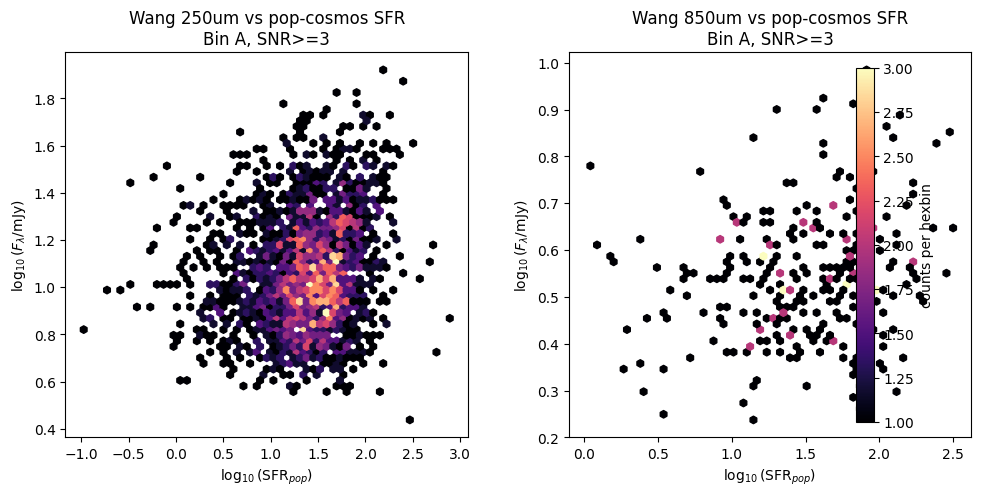

,group,N,median_log10SFR_pop,median_log10M_pop
0,long_detected,2673,1.424736,10.742480
1,not_long_detected,34476,0.862223,10.142872


In [17]:
wang_flux_csv = OUT_DIR / "popcosmos_wang_flux_vs_sfr_summary.csv"
wang_flux_summary.to_csv(wang_flux_csv, index=False)
print("Saved:", wang_flux_csv)

plot_mask_250 = wang_binA & np.isfinite(wang_matched["F250"]) & np.isfinite(wang_matched["SNR250"]) & (wang_matched["SNR250"] >= 3) & (wang_matched["F250"] > 0)
plot_mask_850 = wang_binA & np.isfinite(wang_matched["F850"]) & np.isfinite(wang_matched["SNR850"]) & (wang_matched["SNR850"] >= 3) & (wang_matched["F850"] > 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mask, col, title in [
    (axes[0], plot_mask_250, "F250", "Wang 250um vs pop-cosmos SFR"),
    (axes[1], plot_mask_850, "F850", "Wang 850um vs pop-cosmos SFR"),
]:
    d = wang_matched.loc[mask, ["log10SFR_pop", col]].copy()
    d[f"log10_{col}"] = np.log10(d[col])
    hb = ax.hexbin(d["log10SFR_pop"], d[f"log10_{col}"], gridsize=55, mincnt=1, cmap="magma")
    ax.set_xlabel(r"$\log_{10}(\mathrm{SFR}_{pop})$")
    ax.set_ylabel(r"$\log_{10}(F_{\lambda}/\mathrm{mJy})$")
    ax.set_title(title + "\nBin A, SNR>=3")

cbar = fig.colorbar(hb, ax=axes, location="right", shrink=0.92, pad=0.02)
cbar.set_label("counts per hexbin")
plt.subplots_adjust(wspace=0.25, right=0.88)
plt.show()

wang_detect_compare = pd.DataFrame(
    {
        "group": ["long_detected", "not_long_detected"],
        "N": [
            int((wang_binA & wang_matched["long_detect"]).sum()),
            int((wang_binA & ~wang_matched["long_detect"]).sum()),
        ],
        "median_log10SFR_pop": [
            float(np.nanmedian(wang_matched.loc[wang_binA & wang_matched["long_detect"], "log10SFR_pop"])),
            float(np.nanmedian(wang_matched.loc[wang_binA & ~wang_matched["long_detect"], "log10SFR_pop"])),
        ],
        "median_log10M_pop": [
            float(np.nanmedian(wang_matched.loc[wang_binA & wang_matched["long_detect"], "log10M_pop"])),
            float(np.nanmedian(wang_matched.loc[wang_binA & ~wang_matched["long_detect"], "log10M_pop"])),
        ],
    }
)
wang_detect_compare

Quick reading:

- if long-detected galaxies have higher median pop-cosmos SFR and mass, that is at least qualitatively sensible
- if the flux-vs-SFR trend is weak, it means I should be careful about over-interpreting the Wang split without deriving an IR-based SFR

## Step 15: Main-sequence plane in narrower redshift bins

The earlier MS-plane figure used a broad `1 <= z < 2` bin.

Here I split that into narrower bins:
- `1.0 <= z < 1.5`
- `1.5 <= z < 2.0`

This reduces the amount of redshift evolution mixed into each panel.

C:\Users\Mihir Koka\AppData\Local\Temp\ipykernel_50908\2606392044.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


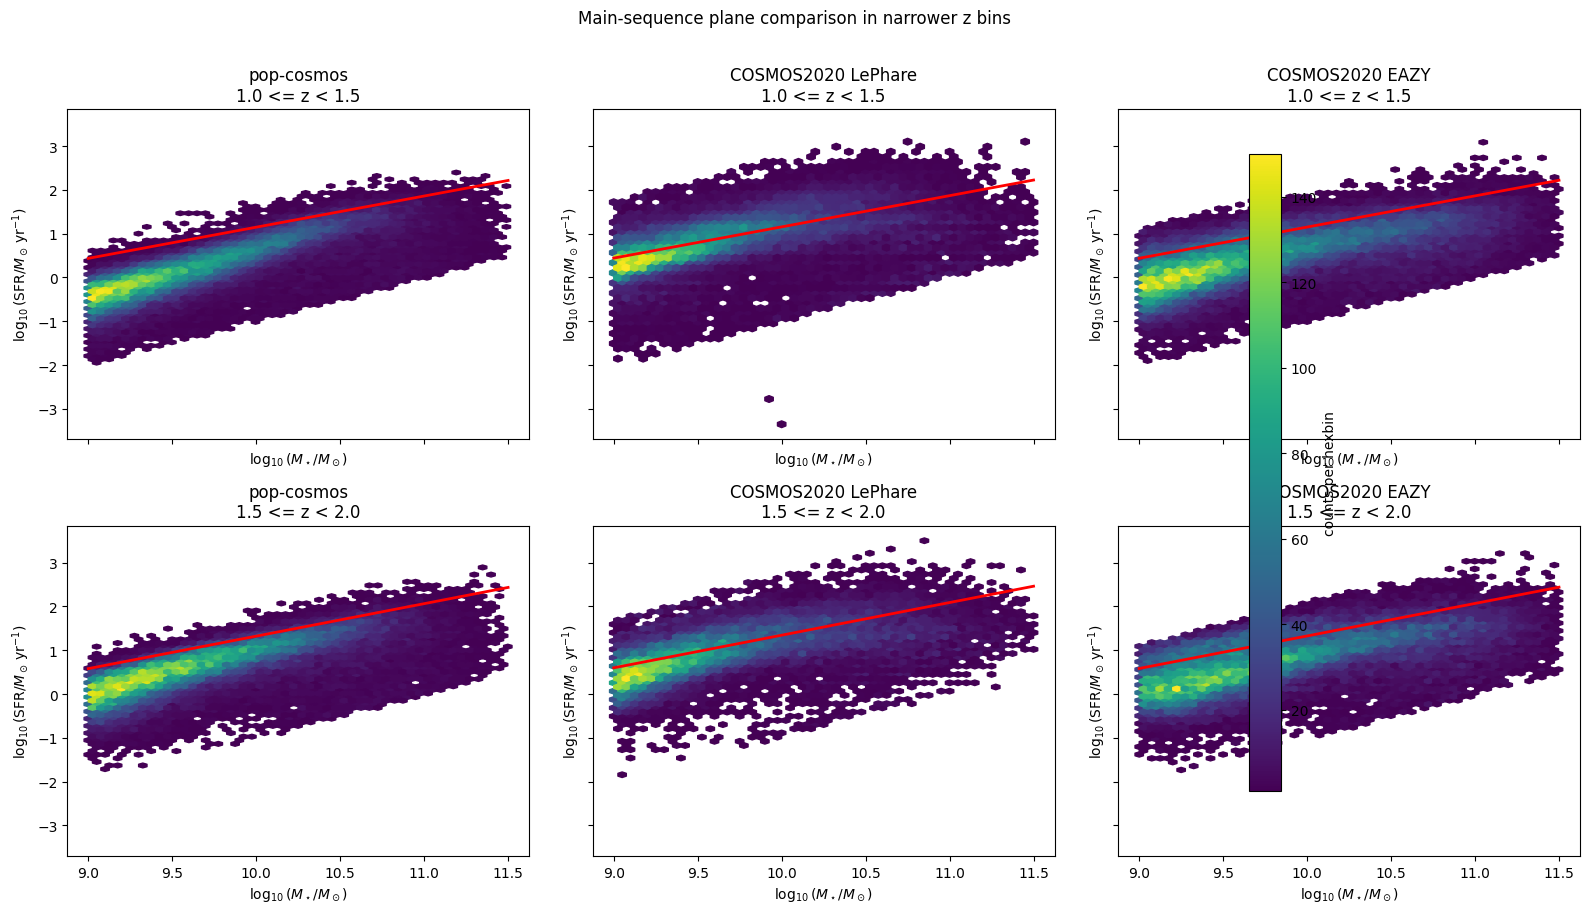

In [17]:
narrow_bins = [
    ("1.0 <= z < 1.5", 1.0, 1.5),
    ("1.5 <= z < 2.0", 1.5, 2.0),
]

def plot_ms_row(ax, work_df, title, zlo, zhi):
    base = sf_base_mask(work_df)
    m = base & (work_df["z"] >= zlo) & (work_df["z"] < zhi) & (work_df["log10M"] >= 9.0) & (work_df["log10M"] <= 11.5)
    d = work_df.loc[m].copy()
    if len(d) == 0:
        ax.set_title(title + "\n(no data)")
        return None
    hb = ax.hexbin(d["log10M"], d["log10SFR"], gridsize=50, mincnt=1, cmap="viridis")
    z_med = np.nanmedian(d["z"])
    x = np.linspace(9.0, 11.5, 120)
    ax.plot(x, speagle_log10sfr(x, np.full_like(x, z_med)), "r-", lw=2)
    ax.set_xlabel(r"$\log_{10}(M_\star/M_\odot)$")
    ax.set_ylabel(r"$\log_{10}(\mathrm{SFR}/M_\odot\,\mathrm{yr}^{-1})$")
    ax.set_title(title + f"\n{zlo} <= z < {zhi}")
    return hb

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
for row, (label, zlo, zhi) in enumerate(narrow_bins):
    hb0 = plot_ms_row(axes[row, 0], pop_work, "pop-cosmos", zlo, zhi)
    hb1 = plot_ms_row(axes[row, 1], lp_work, "COSMOS2020 LePhare", zlo, zhi)
    hb2 = plot_ms_row(axes[row, 2], ez_work, "COSMOS2020 EAZY", zlo, zhi)

cbar = fig.colorbar(hb2 if hb2 is not None else hb1 if hb1 is not None else hb0, ax=axes, location="right", shrink=0.92, pad=0.02)
cbar.set_label("counts per hexbin")
plt.suptitle("Main-sequence plane comparison in narrower z bins", y=1.01)
plt.subplots_adjust(wspace=0.22, hspace=0.28, right=0.88, top=0.92)
plt.show()

What I want to look for here:

- whether the broad-bin differences were partly caused by mixing too much redshift evolution together
- whether the relative ordering of pop-cosmos / LePhare / EAZY stays the same when I narrow the bin

If the same pattern survives in both narrower bins, that is stronger evidence the difference is method-related, not just bin-width related.

## Step 17: Mass/luminosity function note (`1 / V_max`)

This is a standard next step, but I am treating it as methodology only for now.

Why can't I yet

- a proper `1 / V_max` mass or luminosity function needs a clear survey selection limit
- it also needs a consistent way to compute `z_max` for each object
- and ideally a completeness cut or mask treatment

The current matched notebook is good for direct estimator comparisons, but not yet clean enough for a publishable function measurement.

If I do this next, the simple plan is:

1. choose one parent selection band and magnitude limit
2. compute `z_max` for each galaxy under that selection
3. sum `1 / V_max` in bins of mass or luminosity
4. compare the resulting curves across pop-cosmos / LePhare / EAZY in the same redshift bin

## Extra quick summary from the new sections

- Direct SFR comparison is the cleanest immediate check across pop-cosmos and COSMOS2020, because all three already have SFR columns locally.
- Wang is still useful, but with the currently downloaded file it is a flux-vs-SFR consistency test, not a direct SFR-vs-SFR comparison.
- Narrower redshift bins are a good idea because they reduce redshift evolution inside a single MS panel.
- Direct spec-z benchmarking is not possible from the currently downloaded Farmer and pop-cosmos summary files alone if no spec-z field is present locally.